In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [32]:

# df_original = pd.read_csv('Children Recode_final.csv')
# df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
# df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
# df.head()
# df.shape

# X = df.drop(columns=['Malnurished'])
# y = df['Malnurished']

# # Train-test Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state= 12)

# columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
# scaler = StandardScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
# X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])
# X_train_scaled.head()

# sm = SMOTE(random_state=42)
# X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)
# print('Before SMOTE: ', Counter(y_train))
# print('After SMOTE: ', Counter(y_train_sm))

# tree = DecisionTreeClassifier(
#     class_weight='balanced',
#     max_depth=5,
#     min_samples_leaf=10
# )
# tree.fit(X_train_sm, y_train_sm)

# y_pred = tree.predict(X_test_scaled)
# print(accuracy_score(y_test, y_pred))
# pd.crosstab(y_test, y_pred)

# # Classification Report
# print(classification_report(y_test, y_pred))

### Load Dataset

In [33]:
# Load Data
df_original = pd.read_csv('df.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)

# Train-test Split
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify = y, random_state = 42)

In [34]:

print(df.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(2205, 37)
Malnurished
0    1168
1     596
Name: count, dtype: int64
Malnurished
0    292
1    149
Name: count, dtype: int64


**Standard Scaler**


In [35]:
columns_to_scale = ['Child_age', 'BMI', 'Mother_age_current']
scaler = StandardScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

## Model Fit

In [36]:
clf = DecisionTreeClassifier(criterion='gini', 
                             class_weight='balanced', 
                             random_state=42,
                             max_depth=5)  # You can adjust max_depth to control model complexity
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[136 156]
 [ 53  96]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.47      0.57       292
           1       0.38      0.64      0.48       149

    accuracy                           0.53       441
   macro avg       0.55      0.56      0.52       441
weighted avg       0.61      0.53      0.54       441



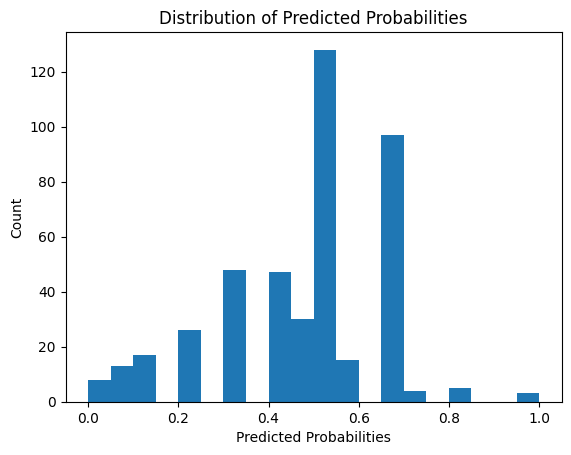

In [37]:
y_probas = clf.predict_proba(X_test)[:, 1]
plt.hist(y_probas, bins=20)
plt.xlabel('Predicted Probabilities')
plt.ylabel('Count')
plt.title('Distribution of Predicted Probabilities')
plt.show()

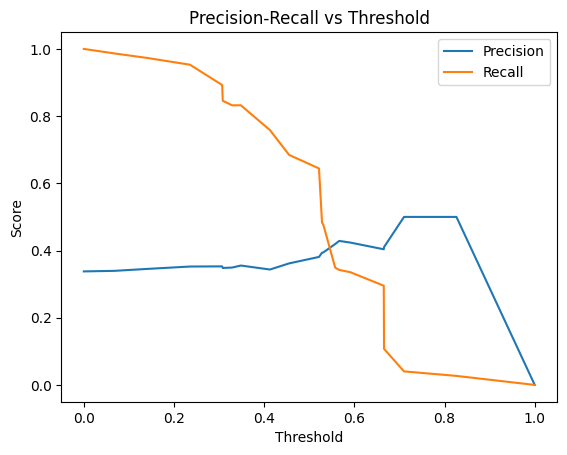

In [38]:
from sklearn.metrics import precision_recall_curve

y_probas = clf.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.show()

In [39]:
y_probas = clf.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)

print(f'Confusion Matrix: \n{pd.crosstab(y_test, y_probas_custom)}\n')
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Confusion Matrix: 
col_0         0    1
Malnurished         
0            76  216
1            36  113

Classification Report: 
              precision    recall  f1-score   support

           0       0.68      0.26      0.38       292
           1       0.34      0.76      0.47       149

    accuracy                           0.43       441
   macro avg       0.51      0.51      0.42       441
weighted avg       0.57      0.43      0.41       441




In [40]:
from sklearn.metrics import average_precision_score
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.38530387287099627


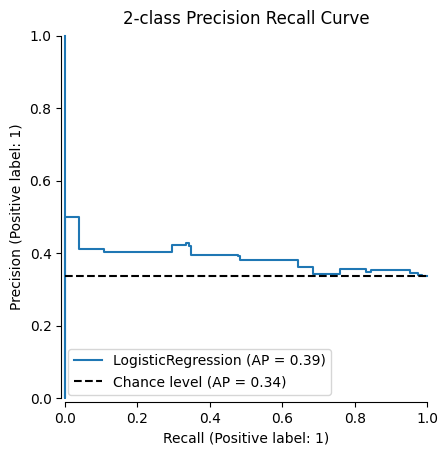

In [41]:
from sklearn.metrics import PrecisionRecallDisplay
display = PrecisionRecallDisplay.from_estimator(
    clf,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
    despine = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

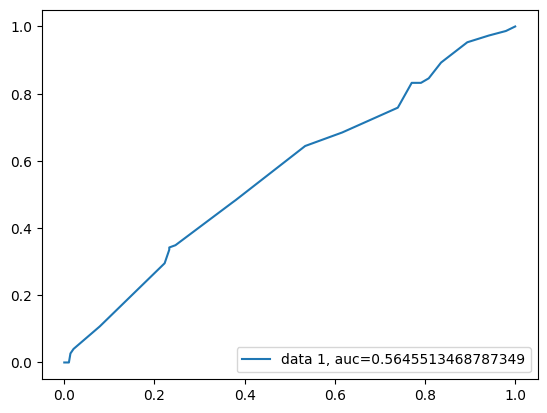

In [42]:
from sklearn import metrics
y_probas_custom = clf.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_probas_custom)
auc = metrics.roc_auc_score(y_test, y_probas_custom)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()